First we load few servce libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline   # to render plots directly inside the notebook, right below the code cell that produced them, instead of opening a separate interactive window.

# Creation of the Dense ANN

What libraries will we need?

We will need 3 sets of tools from the library Tensorflow - Keras.

We will not load full library - it is huge - just the tools which we need.


In [58]:
from tensorflow.keras.models import Sequential  # Class Sequential - is used for construction of the ANN
from tensorflow.keras.layers import Dense       # Class Dense - to make the layer of neurons (Dense = a fully connected layer, Each neuron in the layer connects to every neuron in the previous layer.)
from tensorflow.keras import utils              # Some tools for data preparation (utils provides helper functions for common tasks. Example: to converts class labels into one-hot encoded vectors)

We use library KERAS and import Sequential from it to create a frame of the model

In [4]:
model = Sequential() # empty frame

Next step: we have to **COMPILE** the model.

Here we need to specify the **LOSS FUNCTION** and **OPTIMIZER**

In [5]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam')

Now we can make a different model with 3 layer of neurons:

In [6]:
model = Sequential()
model.add(Dense(32, input_dim=10))
model.add(Dense(5))
model.add(Dense(1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 523 (2.04 KB)

 Trainable params: 523 (2.04 KB)

 Non-trainable params: 0 (0.00 B)

# Recognition of the handwritten numbers **MNIST**

## Preparation of the data

We have to add one more library - the library of hand-written numbers **mnist**


In [7]:
from tensorflow.keras.datasets import mnist

Now we need to split the datasets for training and testing the model - these will hand-written numbers from **0** to **9** as an input x and their lables as outputs y:
* **x_train_org**, **y_train_org** – the set for training;
* **x_test_org**, **y_test_org** – the set for testing.


In [8]:
# Loading data from  Mnist
(x_train_org, y_train_org), (x_test_org, y_test_org) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Each of the images that we have downloaded are represented as the matrices filled with rhe numbers from **0** to  **255** - the brightness of the pixels. There are **60000** such images in the train set and the size of each one is  **28** by **28** pixel.

In [9]:
x_train_org.shape
# x_test_org.shape

(60000, 28, 28)

In [10]:
y_train_org.shape

(60000,)

In [11]:
x_test_org.shape

(10000, 28, 28)

In [12]:
y_test_org.shape

(10000,)

Let's check that theses are really images of the handwritten numbers.

Chose from **x_train_org** one of these matrices 28x28 and plot it as a greyscale image:

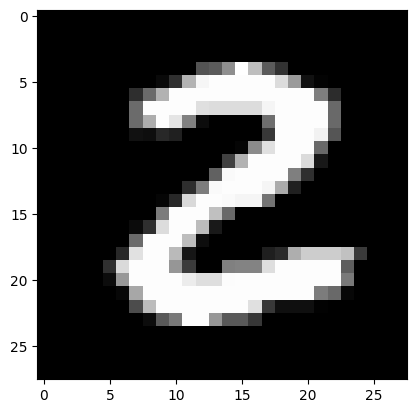

In [13]:
# Chose any number
n = 25

# plot corresponding matrix as an image
plt.imshow(x_train_org[n], cmap='gray')

plt.show()

This is an input x, it goes along with the desired outputy - the **LABEL** of this image

In [14]:
# Printing the label of the image
print(y_train_org[n])

2


To use our images in the model we need to transfer all the 2-dimentional matrices into 1-dimentional vectors.
This can be done using the method reshape `.reshape()`:


In [15]:
# Reshaping input data from 28х28 (x_train_org) to 784 (x_train)

x_train = x_train_org.reshape(x_train_org.shape[0], -1)
x_test = x_test_org.reshape(x_test_org.shape[0], -1)

# ПChecking
print(f'Training input data: {x_train_org.shape} -> {x_train.shape}')
print(f'Testing input data: {x_test_org.shape} -> {x_test.shape}')

Training input data: (60000, 28, 28) -> (60000, 784)
Testing input data: (10000, 28, 28) -> (10000, 784)


Now each input is a sequence of **784** numbers **(28x28)** with the values from 0 to 255. We would prefer to work with the numbers in a range from **0** to  **1**,for this we will devide all of them by **255**. This is named **NORMALIZATION** of the input data:


In [16]:
# Normalization of input data
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

The LABELS of the images also have to be transfered to the different shape which is named ***one hot encoding***.

It means that each number will be transfered into the vector of length **10** with the values **0** or **1** at each position.   In this **one hot encoding** vector, every other values will be 0 except at the position of its true label - which will be 1.

Example:
* If label number is **5**,  one hot encoding will be:

      [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]

* for the label **3** it will be:

      [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]


In [17]:
# To be more general we will specify the number of classes as a constant

CLASS_COUNT = 10

Transformation of the initial labels to the one hot encoding format can be done using function `to_categorical()` from the library **utils**:

In [18]:
# transformation to one_hot_encoding
y_train = utils.to_categorical(y_train_org, CLASS_COUNT)
y_test = utils.to_categorical(y_test_org, CLASS_COUNT)

Let's check what we got:

In [19]:
# The shape of y_train
# 60 vectors, each one of length 10 as the total number of ckasses
print(y_train.shape)

(60000, 10)


In [20]:
# Let's see how this vector looks like
print(y_train[n])

[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


## Creation of the ANN model

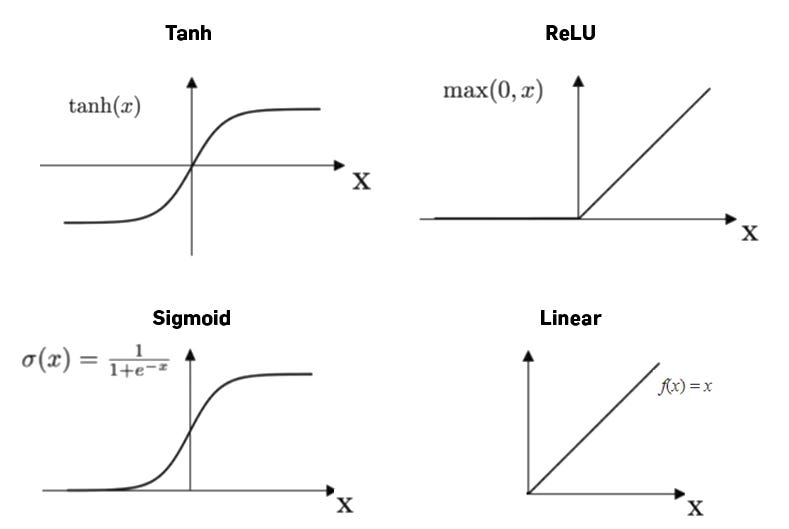

# Try to change the following: (1) number of neurons/layers, (2) number of layers (3) activation function of hidden layers

In [21]:
# Creation of the empty frame
model = Sequential()

# Adding a single dense layer with 800 neurons, for 784 inputs and activation function ReLu
model.add(Dense(80, input_dim=784, activation='relu'))

# Adding a single dense layer with 400 neurons and activation function ReLu (# explore tanh, sigmoid, relu)
model.add(Dense(40, activation='relu'))

# Adding a single dense layer with 400 neurons and activation function ReLu
model.add(Dense(10, activation='relu'))

# Adding a single dense layer with the number of neurons corresponding to the number of classes and activation function Softax
model.add(Dense(CLASS_COUNT, activation='softmax'))



Next step: we compile the model

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In the method `.compile()` we specify Loss Function (**'categorical_crossentropy'**), Optimiser (**'adam'**) and the metrics of accuracy which will be calculated during training process (**['accuracy']**).



In [22]:
# Compilation of the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Model summary
print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 80)             │        62,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           410 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,560 (260.00 KB)

 Trainable params: 66,560 (260.00 KB)

 Non-trainable params: 0 (0.00 B)

None


Function `plot_model()` from the library `utils` can plot the summary in the form of a cheme - it is especially convinient when the model is complex.

This function has following arguments
* **model** - the name of the model (compulsory);
* **to_file** - the name of the file to save the sheme (compulsory);
* **show_shapes** - whether to show the shapes of input and output (optional, by defolt **False**);
* **show_layer_names** - whether to show the name of the layer (optional, by default **True**).

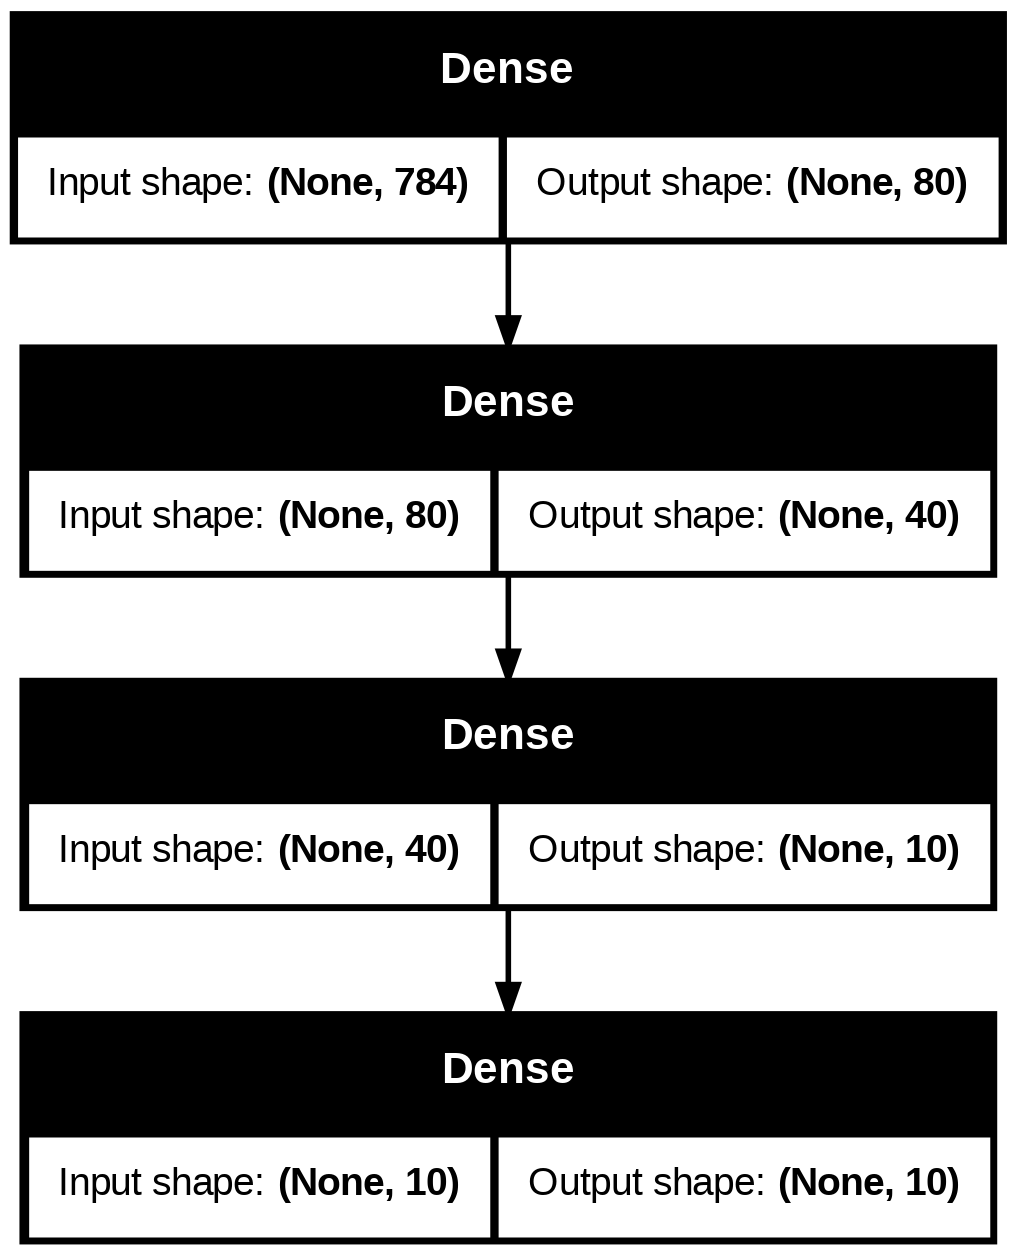

In [23]:
utils.plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=False)

## Training (fitting) of ANN model

Now we start training the ANN model

For this we use the command `.fit()` and providing for the training 6000 couples **x_train, y_train** which are input 784 long vector containing transfered image and a desired output 10 long vector representing the label :

    model.fit(x_train, y_train, batch_size=128, epochs=15, verbose=1)

**batch_size** – the size of the batch - shows how many images it will process at a time.

**epochs** – number of the cycles of training - how many times ANN will go through all your data .


# Try to change the number of epochs and observe the results

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6950 - loss: 0.9168
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9466 - loss: 0.1907
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9606 - loss: 0.1303
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9695 - loss: 0.1024
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9738 - loss: 0.0856
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9787 - loss: 0.0715
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9821 - loss: 0.0596
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9840 - loss: 0.0506
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9865 - loss: 0.0455
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9871 - loss: 0.0413
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9902 - loss: 0.0331
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

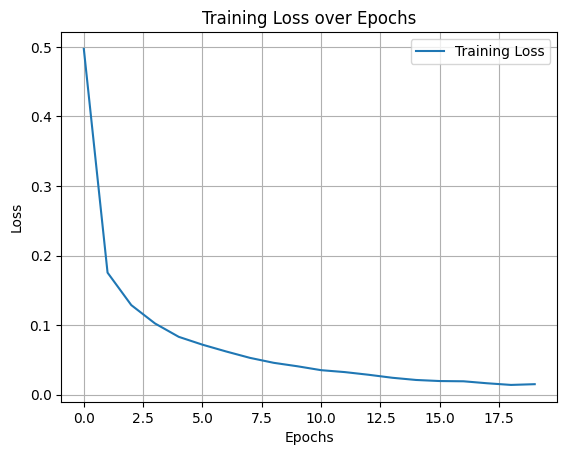

In [24]:
# Training the model and store the training history
# history = model.fit(x_train, y_train, batch_size=128, epochs=15, verbose=1)


history= model.fit(x_train,        # training set, inputs
                   y_train,        # training set, outputs
                   batch_size=128, # batch size
                   epochs=20,      # number of epoches (cycles of study)
                   verbose=1)      # 0 - don't show fitting process, 1 - show fitting process

# Plotting the training loss over epochs
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

During this training process, the weights of the model were first rendomly set and the refined at each iteration. Obtained weights can be saved and then loaded for the further utilisation.


In [25]:
model.save_weights('model.weights.h5') # to save the weights into a file
model.load_weights('model.weights.h5') # to load from the specified file

 Testing the model with unseen data

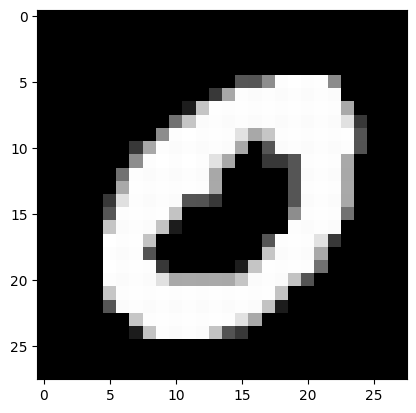

In [36]:
# Let's randomly chose some number from the testing set which didn't participate in the training process
n_rec = np.random.randint(x_test_org.shape[0])

# Plotting the picked up image
plt.imshow(x_test_org[n_rec], cmap='gray')
plt.show()



Now we need to transfer this image to a 1D vectot of size 784 to be able to supply it to the input of the model.

We already have done it before while preparing data, so now we can just get the corresponding vector from x_test


In [37]:
# getting corresponding input vector
x = x_test[n_rec]

# Checking the shape
print(x.shape)

(784,)


In [38]:
# Adding the axis to fit the requirements of the model (as it uses bathes, one single vector should be represented as a batch of 1 item)
x = np.expand_dims(x, axis=0)

# Shape check
print(x.shape)

(1, 784)


In [40]:
# Prediction
prediction = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [42]:
# printing the prediction
print(prediction)

[[1.0000000e+00 2.9398317e-18 1.6627727e-10 1.7273209e-19 2.6887742e-24
  3.0885040e-20 2.4370889e-15 5.4927297e-17 2.7209986e-16 2.5195358e-14]]


In [44]:
sum(prediction[0])

np.float32(1.0)

In [46]:
# Getting the index of the biggest element of the vector
pred = np.argmax(prediction)
print(f'The hand-written number is: {pred}')

The hand-written number is: 0


In [48]:
# Correct answer?
print(y_test_org[n_rec])

0


## Recognizing Handwritten Numbers

# Recognizing our own handwriting


Saving number_four.jpg to number_four (1).jpg
Processed image saved as processed_digit.png


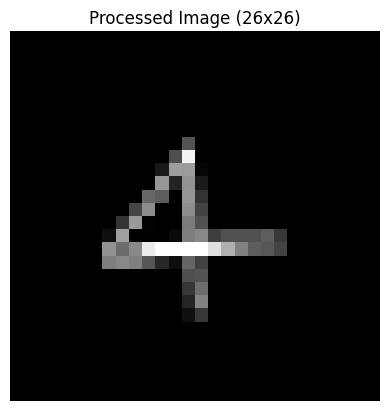

Pixel matrix (26x26):
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 

In [50]:
from google.colab import files
from PIL import Image, ImageOps, ImageEnhance
import numpy as np
import matplotlib.pyplot as plt

def upload_and_preprocess_image():

    # Step 1: Draw any digit of your choice from 0 to 9.
    # Note: It is better to draw the digit digitally (using your phone or ipad) or in a pure white paper with a dark ink
    # Save the drawn image in a common image format (eg. jpeg) locally in your computer
    # Upload your handwritten image file from computers local drive
    uploaded = files.upload()
    file_name = next(iter(uploaded))

    # Opening the uploaded image
    img = Image.open(file_name)

    # Resizing based on requirements, in our case 28x28
    img_resized = img.resize((28, 28))

    # Greyscale conversion and contrast adjustments
    img_gray = img_resized.convert('L')
    enhancer = ImageEnhance.Contrast(img_gray)
    img_contrasted = enhancer.enhance(2.0)  # Adjust the factor for more contrast if needed

    # Invert colors (changing blacks to white and vice versa, because we trained NN based on white numbers in black background)
    img_inverted = ImageOps.invert(img_contrasted)

    # Saving
    output_image_path = "processed_digit.png"
    img_inverted.save(output_image_path)
    print(f"Processed image saved as {output_image_path}")

    # pixel value matrix (with numbers from 0 to 255)
    pixel_values = np.array(img_inverted)

    # Displaying the final image
    plt.imshow(pixel_values, cmap='gray')
    plt.title("Processed Image (26x26)")
    plt.axis('off')  # Hide axis for better visualization
    plt.show()

    return pixel_values

pixels = upload_and_preprocess_image()

# Displaying the pixel matrix
if pixels is not None:
    print(f"Pixel matrix (26x26):\n{pixels}")


In [51]:
#Testing your own handwritten digit
x =pixels
# reshaping
x = x.reshape(-1)
# Normalization of input data
x = x.astype('float32') / 255.
x.shape

(784,)

Now we need to transfer this image to a 1D vectot of size **784** to be able to supply it to the input of the model.

We already have done it before while preparing data, so now we can just get the corresponding vector from **x_test**

In [52]:
# Adding the axis to fit the requirements of the model (as it uses bathes, one single vector should be represented as a batch of 1 item)
x = np.expand_dims(x, axis=0)

# Shape check
print(x.shape)

(1, 784)


Using method `.predict()` with the input vector as an itput:


In [53]:
# Prediction
prediction = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


The prediction will be the array of to numbers showing the probability of belonging of the picture to one of ten classes:


In [54]:
# printing the prediction
print(prediction)

[[7.2911243e-06 2.5632924e-03 2.0313283e-02 2.7514462e-04 9.7046417e-01
  4.3317523e-05 1.1240956e-05 6.7568128e-04 3.7739144e-05 5.6089447e-03]]


In [55]:
sum(prediction[0])

np.float32(1.0000001)

The index value of the biggest number in this vector will be the predicted number:

In [57]:
# Getting the index of the biggest element of the vector
pred = np.argmax(prediction)
print(f'You have written: {pred}')

You have written: 4
